In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import random
import os
import math

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

SEED = 42
seed_everything(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# ======================================================
# [V12] Y축 데이터 증강 + MDN
# ======================================================
BATCH_SIZE = 64
LR_BASE = 1e-3
WARMUP_EPOCHS = 3
EPOCHS_BASE = 50
DROPOUT = 0.2
MAX_SEQ_LEN = 30
GRAD_CLIP = 1.0

HIDDEN_DIM = 256
LSTM_LAYERS = 3
BIDIRECTIONAL = True

# MDN 파라미터
NUM_GAUSSIANS = 2
MIN_SIGMA = 0.01
MAX_SIGMA = 0.3
HYBRID_LOSS_WEIGHT = 0.3

print(f"[V12] Y축 데이터 증강 + MDN")
print(f"  주요 기능:")
print(f"  1. ✅ Y축 반전 데이터 증강 (사이드라인 대칭성 활용)")
print(f"  2. MDN (2 Gaussians)")
print(f"  3. Spatial-Temporal Attention")
print(f"  4. Hybrid Loss (NLL + MSE)")

Device: cuda
[V12] Y축 데이터 증강 + MDN
  주요 기능:
  1. ✅ Y축 반전 데이터 증강 (사이드라인 대칭성 활용)
  2. MDN (2 Gaussians)
  3. Spatial-Temporal Attention
  4. Hybrid Loss (NLL + MSE)


c:\Anaconda3\envs\daycon\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ======================================================
# 데이터 로드 (증강은 나중에!)
# ======================================================
BASE_DIR = "./open_track1"
if not os.path.exists(BASE_DIR): BASE_DIR = "."

TRAIN_PATH = os.path.join(BASE_DIR, "train.csv")
TEST_META_PATH = os.path.join(BASE_DIR, "test.csv")
MATCH_PATH = os.path.join(BASE_DIR, "match_info.csv")

train_df = pd.read_csv(TRAIN_PATH)
print(f"✅ Train Loaded: {train_df.shape}")

if os.path.exists(TEST_META_PATH):
    test_meta = pd.read_csv(TEST_META_PATH)
    print(f"ℹ️ Reading {len(test_meta)} test files...")
    test_dfs = []
    for _, row in tqdm(test_meta.iterrows(), total=len(test_meta), desc="Loading Test CSVs"):
        rel_path = row['path']
        paths_to_try = [
            rel_path,
            os.path.join(BASE_DIR, rel_path.lstrip("./")),
            os.path.join(BASE_DIR, "test", str(row['game_id']), os.path.basename(rel_path))
        ]
        for p in paths_to_try:
            if os.path.exists(p):
                test_dfs.append(pd.read_csv(p))
                break
    if test_dfs:
        test_df = pd.concat(test_dfs, ignore_index=True)
        print(f"✅ Test Data Merged: {test_df.shape}")
else:
    raise FileNotFoundError("test.csv not found")

if os.path.exists(MATCH_PATH):
    match_info = pd.read_csv(MATCH_PATH)
    match_subset = match_info[['game_id', 'home_team_id', 'venue']]
    train_df = pd.merge(train_df, match_subset, on='game_id', how='left')
    test_df = pd.merge(test_df, match_subset, on='game_id', how='left')

def preprocess(df):
    if 'home_team_id' in df.columns:
        df['is_home'] = (df['team_id'] == df['home_team_id']).astype(float)
    else:
        df['is_home'] = 0.5
    if 'end_x' not in df.columns:
        df['end_x'] = 0.0
        df['end_y'] = 0.0
    else:
        df['end_x'] = df['end_x'].fillna(0.0)
        df['end_y'] = df['end_y'].fillna(0.0)
    return df

train_df = preprocess(train_df)
test_df = preprocess(test_df)

ID_COL = 'game_episode' if 'game_episode' in train_df.columns else 'episode_id'
print(f"\nData Ready. ID Column: {ID_COL}")
print(f"⚠️ 데이터 증강은 train/val split 후에 적용됩니다 (데이터 유출 방지)")

✅ Train Loaded: (356721, 15)
ℹ️ Reading 2414 test files...


Loading Test CSVs: 100%|██████████| 2414/2414 [00:28<00:00, 84.52it/s]


✅ Test Data Merged: (53110, 15)

Data Ready. ID Column: game_episode
⚠️ 데이터 증강은 train/val split 후에 적용됩니다 (데이터 유출 방지)


In [ ]:
# ======================================================
# [V15] 피처 엔지니어링 + N-gram (type + result 조합)
# ======================================================
TOP_TYPES = ['Pass', 'Carry', 'Recovery', 'Interception', 'Duel', 'Tackle', 
             'Throw-In', 'Clearance', 'Intervention', 'Block', 'Pass_Freekick', 
             'Cross', 'Goal Kick', 'Error', 'Shot']
ALL_RESULTS = ['Successful', 'Unsuccessful', 'On Target', 'Yellow_Card', 
               'Blocked', 'Keeper Rush-Out', 'Low Quality Shot', 'Off Target']

# 🆕 N-gram 패턴 (type + result 조합)
TOP_3GRAMS = []
TOP_5GRAMS = []
NGRAM_3_SIZE = 20
NGRAM_5_SIZE = 20

# 패턴 to index 매핑 (Embedding용)
PATTERN_3_TO_IDX = {}
PATTERN_5_TO_IDX = {}

def extract_ngrams_from_data(df, n_size=3, top_k=20):
    """
    type_name + result_name 조합으로 N-gram 패턴 추출
    
    예: "Pass_Successful" -> "Carry_Successful" -> "Pass_Successful"
    """
    from collections import Counter
    patterns = []

    for _, group in df.groupby(ID_COL, sort=False):
        # type + result 조합
        combined = [
            f"{t}_{r}" if pd.notna(r) and r else t
            for t, r in zip(group['type_name'].values, group['result_name'].values)
        ]
        
        for i in range(n_size - 1, len(combined)):
            pattern = tuple(combined[i - n_size + 1 : i + 1])
            patterns.append(pattern)

    # 빈도 계산 및 상위 K개 추출
    counter = Counter(patterns)
    top_patterns = [p for p, _ in counter.most_common(top_k)]
    
    print(f"\n🔍 {n_size}-gram 패턴 분석 (type+result):")
    print(f"   전체 유니크 패턴: {len(counter)}")
    print(f"   상위 {top_k}개:")
    for i, (pattern, count) in enumerate(counter.most_common(min(10, top_k)), 1):
        pattern_str = ' → '.join(pattern)
        print(f"      {i}. {pattern_str}: {count:,}회")
    
    return top_patterns


def make_features(group):
    """
    피처 생성 + N-gram 인덱스 반환
    """
    n = len(group)
    sx = group['start_x'].values / 105.0
    sy = group['start_y'].values / 68.0
    ex = group['end_x'].values / 105.0
    ey = group['end_y'].values / 68.0
    is_home = group['is_home'].values
    
    if 'time_seconds' in group.columns:
        times = group['time_seconds'].values
        dt = np.zeros(n, dtype=np.float32)
        dt[1:] = times[1:] - times[:-1]
        dt = np.maximum(dt, 0.1)
    else:
        dt = np.ones(n, dtype=np.float32)

    dx = ex - sx
    dy = ey - sy
    dist_meter = np.sqrt((dx*105)**2 + (dy*68)**2)
    cumsum_dx = np.cumsum(dx) / 105.0
    cumsum_dy = np.cumsum(dy) / 68.0
    lag_dist_m = np.roll(dist_meter, 1); lag_dist_m[0] = 0
    lag_cumsum_dx = np.roll(cumsum_dx, 1); lag_cumsum_dx[0] = 0
    lag_cumsum_dy = np.roll(cumsum_dy, 1); lag_cumsum_dy[0] = 0
    lag_dt = np.roll(dt, 1); lag_dt[0] = 1.0
    lag_speed = lag_dist_m / np.maximum(lag_dt, 0.1)
    
    if 'player_id' in group.columns:
        p_ids = group['player_id'].values
        is_same = np.zeros(n, dtype=np.float32)
        is_same[1:] = (p_ids[1:] == p_ids[:-1]).astype(np.float32)
    else:
        is_same = np.zeros(n, dtype=np.float32)

    progress = np.arange(n) / max(n-1, 1)
    is_second_half = (group['period_id'].values > 1).astype(np.float32) if 'period_id' in group.columns else np.zeros(n)
    
    GOAL_X, GOAL_Y = 105.0, 34.0
    sx_real, sy_real = sx * 105.0, sy * 68.0
    dist_to_goal = np.sqrt((sx_real - GOAL_X)**2 + (sy_real - GOAL_Y)**2) / 105.0
    angle_to_goal = np.arctan2(GOAL_Y - sy_real, GOAL_X - sx_real)
    angle_sin, angle_cos = np.sin(angle_to_goal), np.cos(angle_to_goal)
    dist_to_sideline = np.minimum(sy_real, 68.0 - sy_real) / 68.0
    dist_to_endline = np.minimum(sx_real, 105.0 - sx_real) / 105.0
    
    def get_zone(x_norm):
        if x_norm < 35.0/105.0: return 0
        elif x_norm < 70.0/105.0: return 1
        else: return 2
    
    zones = np.array([get_zone(x) for x in sx])
    zone_onehot = np.zeros((n, 3), dtype=np.float32)
    for i, z in enumerate(zones): zone_onehot[i, z] = 1.0
    
    types_onehot = np.zeros((n, len(TOP_TYPES) + 1), dtype=np.float32)
    for i, t in enumerate(group['type_name'].values):
        types_onehot[i, TOP_TYPES.index(t) if t in TOP_TYPES else -1] = 1.0
    
    results_onehot = np.zeros((n, len(ALL_RESULTS) + 1), dtype=np.float32)
    for i, r in enumerate(group['result_name'].values):
        results_onehot[i, ALL_RESULTS.index(r) if r in ALL_RESULTS else -1] = 1.0

    # 🆕 N-gram 인덱스 생성 (Embedding용)
    combined_list = [
        f"{t}_{r}" if pd.notna(r) and r else t
        for t, r in zip(group['type_name'].values, group['result_name'].values)
    ]
    
    ngram3_idx = np.zeros(n, dtype=np.int64)  # 0 = padding
    ngram5_idx = np.zeros(n, dtype=np.int64)
    
    for i in range(n):
        # 3-gram
        if i >= 2:
            pattern = tuple(combined_list[i-2:i+1])
            if pattern in PATTERN_3_TO_IDX:
                ngram3_idx[i] = PATTERN_3_TO_IDX[pattern]
            else:
                ngram3_idx[i] = len(TOP_3GRAMS) + 1  # 'Others' 인덱스
        
        # 5-gram
        if i >= 4:
            pattern = tuple(combined_list[i-4:i+1])
            if pattern in PATTERN_5_TO_IDX:
                ngram5_idx[i] = PATTERN_5_TO_IDX[pattern]
            else:
                ngram5_idx[i] = len(TOP_5GRAMS) + 1  # 'Others' 인덱스

    # 기본 피처 + N-gram 인덱스
    features = []
    ngram3_indices = []
    ngram5_indices = []
    
    for i in range(n):
        scalars = [sx[i], sy[i], lag_cumsum_dx[i], lag_cumsum_dy[i], lag_dist_m[i]/100.0,
                   lag_speed[i]/10.0, dt[i]/10.0, progress[i], is_home[i], is_same[i],
                   is_second_half[i], dist_to_goal[i], angle_sin[i], angle_cos[i],
                   dist_to_sideline[i], dist_to_endline[i]]
        feat_vec = np.concatenate([scalars, zone_onehot[i], types_onehot[i], results_onehot[i]])
        features.append(feat_vec)
        ngram3_indices.append(ngram3_idx[i])
        ngram5_indices.append(ngram5_idx[i])
        
        if i < n - 1:
            ex_real, ey_real = ex[i] * 105.0, ey[i] * 68.0
            end_dist_to_goal = np.sqrt((ex_real - GOAL_X)**2 + (ey_real - GOAL_Y)**2) / 105.0
            end_angle = np.arctan2(GOAL_Y - ey_real, GOAL_X - ex_real)
            scalars_end = scalars.copy()
            scalars_end[0:2] = [ex[i], ey[i]]
            scalars_end[2:4] = [cumsum_dx[i], cumsum_dy[i]]
            scalars_end[11:16] = [end_dist_to_goal, np.sin(end_angle), np.cos(end_angle),
                                   min(ey_real, 68.0 - ey_real) / 68.0,
                                   min(ex_real, 105.0 - ex_real) / 105.0]
            end_zone_onehot = np.zeros(3, dtype=np.float32)
            end_zone_onehot[get_zone(ex[i])] = 1.0
            feat_vec_end = np.concatenate([scalars_end, end_zone_onehot, types_onehot[i], results_onehot[i]])
            features.append(feat_vec_end)
            ngram3_indices.append(ngram3_idx[i])
            ngram5_indices.append(ngram5_idx[i])
            
    return (np.array(features, dtype=np.float32), 
            np.array(ngram3_indices, dtype=np.int64),
            np.array(ngram5_indices, dtype=np.int64))


# 🆕 N-gram 패턴 추출
print("\n" + "="*70)
print("🔍 N-gram 패턴 추출 중 (type+result 조합)...")
print("="*70)

TOP_3GRAMS = extract_ngrams_from_data(train_df, n_size=3, top_k=NGRAM_3_SIZE)
TOP_5GRAMS = extract_ngrams_from_data(train_df, n_size=5, top_k=NGRAM_5_SIZE)

# 인덱스 매핑 생성 (1부터 시작, 0은 padding)
PATTERN_3_TO_IDX = {pattern: idx + 1 for idx, pattern in enumerate(TOP_3GRAMS)}
PATTERN_5_TO_IDX = {pattern: idx + 1 for idx, pattern in enumerate(TOP_5GRAMS)}

print(f"\n✅ N-gram 패턴 추출 완료:")
print(f"   3-gram: {len(TOP_3GRAMS)}개 (+ Others)")
print(f"   5-gram: {len(TOP_5GRAMS)}개 (+ Others)")
print(f"   Embedding vocab size: 3-gram={len(TOP_3GRAMS)+2}, 5-gram={len(TOP_5GRAMS)+2}")
print(f"   (0=padding, 1~{len(TOP_3GRAMS)}=top patterns, {len(TOP_3GRAMS)+1}=others)")
print("="*70)

# INPUT_DIM 계산
dummy_group = train_df.iloc[:5].copy()
dummy_feats, _, _ = make_features(dummy_group)
INPUT_DIM = dummy_feats.shape[1]
print(f"\n✅ Base Input Dimension: {INPUT_DIM}")
print(f"🆕 N-gram은 별도 Embedding Layer로 처리 (모델에서 concat)")

In [ ]:
# ======================================================
# 데이터셋 (N-gram 인덱스 포함)
# ======================================================
class SoccerDataset(Dataset):
    def __init__(self, df, mode='train', augment_y=False):
        """
        augment_y: Y축 반전 증강 여부
        """
        self.mode = mode
        self.augment_y = augment_y
        self.episodes = []
        self.ngram3_indices = []
        self.ngram5_indices = []
        self.targets = []
        self.team_ids = []
        self.episode_ids = []
        
        for name, group in tqdm(df.groupby(ID_COL, sort=False), desc=f"Dataset ({mode})"):
            if mode == 'train' and len(group) < 2: continue
            
            # 원본 추가
            seq, ng3_idx, ng5_idx = make_features(group)
            team_id = group.iloc[0]['team_id']
            
            if mode == 'train':
                last = group.iloc[-1]
                self.targets.append([last['end_x']/105.0, last['end_y']/68.0])
                self.episodes.append(seq)
                self.ngram3_indices.append(ng3_idx)
                self.ngram5_indices.append(ng5_idx)
                self.team_ids.append(team_id)
            else:
                self.episodes.append(seq)
                self.ngram3_indices.append(ng3_idx)
                self.ngram5_indices.append(ng5_idx)
                self.team_ids.append(team_id)
                self.episode_ids.append(str(name))
            
            # 🆕 Y축 증강 (train만!)
            if mode == 'train' and augment_y:
                group_aug = group.copy()
                group_aug['start_y'] = 68.0 - group_aug['start_y']
                group_aug['end_y'] = 68.0 - group_aug['end_y']
                
                seq_aug, ng3_idx_aug, ng5_idx_aug = make_features(group_aug)
                last_aug = group_aug.iloc[-1]
                self.targets.append([last_aug['end_x']/105.0, last_aug['end_y']/68.0])
                self.episodes.append(seq_aug)
                self.ngram3_indices.append(ng3_idx_aug)
                self.ngram5_indices.append(ng5_idx_aug)
                self.team_ids.append(team_id)

    def __len__(self): return len(self.episodes)
    
    def __getitem__(self, idx):
        seq = torch.FloatTensor(self.episodes[idx])
        ng3 = torch.LongTensor(self.ngram3_indices[idx])
        ng5 = torch.LongTensor(self.ngram5_indices[idx])
        
        if len(seq) > MAX_SEQ_LEN:
            seq = seq[-MAX_SEQ_LEN:]
            ng3 = ng3[-MAX_SEQ_LEN:]
            ng5 = ng5[-MAX_SEQ_LEN:]
        
        if self.mode == 'train':
            return seq, ng3, ng5, torch.FloatTensor(self.targets[idx]), self.team_ids[idx]
        return seq, ng3, ng5, self.team_ids[idx], self.episode_ids[idx]


def collate_fn(batch):
    """
    Collate function for N-gram support
    """
    seqs = [b[0] for b in batch]
    ng3s = [b[1] for b in batch]
    ng5s = [b[2] for b in batch]
    
    lens = torch.LongTensor([len(s) for s in seqs])
    
    padded = pad_sequence(seqs, batch_first=True, padding_value=0)
    ng3_padded = pad_sequence(ng3s, batch_first=True, padding_value=0)
    ng5_padded = pad_sequence(ng5s, batch_first=True, padding_value=0)
    
    mask = torch.arange(padded.size(1))[None, :] >= lens[:, None]
    
    # Test mode
    if isinstance(batch[0][4], str):
        return (padded, ng3_padded, ng5_padded, mask, lens, 
                torch.LongTensor([b[3] for b in batch]), 
                [b[4] for b in batch])
    
    # Train mode
    return (padded, ng3_padded, ng5_padded, 
            torch.stack([b[3] for b in batch]), 
            mask, lens, 
            torch.LongTensor([b[4] for b in batch]))


# 데이터셋 생성
full_dataset = SoccerDataset(train_df, mode='train', augment_y=False)
test_dataset = SoccerDataset(test_df, mode='test', augment_y=False)
print(f"✅ Dataset: {len(full_dataset)} episodes (증강 전)")
print(f"✅ Test: {len(test_dataset)} episodes")
print(f"🆕 각 에피소드에 N-gram 인덱스 포함")

In [ ]:
# ======================================================
# [V15] N-gram Embedding 추가 모델
# ======================================================

# N-gram Embedding 설정
NGRAM_EMBED_DIM = 8  # 각 패턴을 8차원 벡터로 표현


class SpatialAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.goal_attn = nn.Sequential(nn.Linear(3, 16), nn.ReLU(), nn.Linear(16, 1))
        self.zone_attn = nn.Sequential(nn.Linear(3, 8), nn.ReLU(), nn.Linear(8, 1))
        self.pos_attn = nn.Sequential(nn.Linear(2, 8), nn.ReLU(), nn.Linear(8, 1))
        self.fusion = nn.Linear(3, 1)
    def forward(self, x):
        return self.fusion(torch.cat([self.pos_attn(x[..., 0:2]), 
                                       self.goal_attn(x[..., 11:14]), 
                                       self.zone_attn(x[..., 16:19])], dim=-1))


class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.pos_encoding = nn.Parameter(torch.randn(1, 100, hidden_dim) * 0.02)
        self.temporal_attn = nn.Sequential(nn.Linear(hidden_dim, hidden_dim // 2), 
                                           nn.Tanh(), nn.Dropout(0.1), 
                                           nn.Linear(hidden_dim // 2, 1))
    def forward(self, lstm_out):
        return self.temporal_attn(lstm_out + self.pos_encoding[:, :lstm_out.size(1), :])


class SpatialTemporalFusion(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.spatial_weight = nn.Parameter(torch.tensor(0.5))
        self.temporal_weight = nn.Parameter(torch.tensor(0.5))
        self.combine = nn.Sequential(nn.Linear(2, 8), nn.ReLU(), nn.Linear(8, 1), nn.Sigmoid())
    def forward(self, s, t):
        return (torch.sigmoid(self.spatial_weight) * s + 
                torch.sigmoid(self.temporal_weight) * t) * self.combine(torch.cat([s, t], -1))


class ImprovedMDNPredictor(nn.Module):
    """
    [V15] N-gram Embedding 추가 모델
    
    🆕 핵심 추가:
    1. 3-gram, 5-gram Embedding Layers
    2. 패턴 간 유사도 학습 가능
    3. type+result 조합으로 풍부한 전술 정보 포착
    """
    def __init__(self, input_dim, hidden_dim, num_layers, dropout, num_gaussians=2, 
                 bidirectional=True, ngram3_vocab_size=22, ngram5_vocab_size=22, ngram_embed_dim=8):
        super().__init__()
        self.num_gaussians = num_gaussians
        
        # 🆕 N-gram Embeddings
        self.ngram3_embed = nn.Embedding(ngram3_vocab_size, ngram_embed_dim, padding_idx=0)
        self.ngram5_embed = nn.Embedding(ngram5_vocab_size, ngram_embed_dim, padding_idx=0)
        
        # Input projection (원본 + ngrams)
        total_input_dim = input_dim + ngram_embed_dim * 2  # 3-gram + 5-gram
        
        self.lstm = nn.LSTM(total_input_dim, hidden_dim, num_layers, batch_first=True,
                           dropout=dropout if num_layers > 1 else 0, bidirectional=bidirectional)
        lstm_output_dim = hidden_dim * 2 if bidirectional else hidden_dim
        
        self.spatial_attn = SpatialAttention(lstm_output_dim)
        self.temporal_attn = TemporalAttention(lstm_output_dim)
        self.fusion = SpatialTemporalFusion(lstm_output_dim)
        
        # MDN Heads
        self.pi_head = nn.Sequential(
            nn.Linear(lstm_output_dim, lstm_output_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(lstm_output_dim // 2, num_gaussians)
        )
        self.mu_head = nn.Sequential(
            nn.Linear(lstm_output_dim, lstm_output_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(lstm_output_dim // 2, num_gaussians * 2)
        )
        self.sigma_head = nn.Sequential(
            nn.Linear(lstm_output_dim, lstm_output_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(lstm_output_dim // 2, num_gaussians * 2)
        )
        
        nn.init.constant_(self.mu_head[-1].bias, 0.5)
        nn.init.xavier_uniform_(self.mu_head[-1].weight, gain=0.1)

    def forward(self, x, ngram3_idx, ngram5_idx, mask=None, lengths=None):
        batch_size, seq_len = x.size(0), x.size(1)
        
        # 🆕 N-gram embeddings
        ng3_emb = self.ngram3_embed(ngram3_idx)  # (batch, seq_len, embed_dim)
        ng5_emb = self.ngram5_embed(ngram5_idx)
        
        # Combine: base features + N-gram embeddings
        x_combined = torch.cat([x, ng3_emb, ng5_emb], dim=-1)
        
        # LSTM
        if lengths is not None:
            packed = pack_padded_sequence(x_combined, lengths.cpu(), batch_first=True, enforce_sorted=False)
            lstm_out, _ = self.lstm(packed)
            lstm_out, _ = pad_packed_sequence(lstm_out, batch_first=True, total_length=seq_len)
        else:
            lstm_out, _ = self.lstm(x_combined)
        
        # Attention
        fused_attn = self.fusion(self.spatial_attn(x), self.temporal_attn(lstm_out))
        if mask is not None:
            fused_attn = fused_attn.masked_fill(mask.unsqueeze(-1), float('-inf'))
        final_attn = torch.softmax(fused_attn, dim=1)
        context = torch.sum(lstm_out * final_attn, dim=1)
        
        # MDN
        pi = torch.softmax(self.pi_head(context), dim=1)
        mu = torch.sigmoid(self.mu_head(context)).view(batch_size, self.num_gaussians, 2)
        sigma_raw = self.sigma_head(context).view(batch_size, self.num_gaussians, 2)
        sigma = torch.sigmoid(sigma_raw) * (MAX_SIGMA - MIN_SIGMA) + MIN_SIGMA
        
        return pi, mu, sigma


def hybrid_mdn_loss(pi, mu, sigma, target, mse_weight=HYBRID_LOSS_WEIGHT):
    """
    Hybrid Loss: NLL + MSE
    """
    batch_size = target.size(0)
    target_expanded = target.unsqueeze(1).expand_as(mu)
    
    # NLL Loss
    diff = target_expanded - mu
    log_prob_components = (
        -0.5 * math.log(2 * math.pi) - torch.log(sigma) - 0.5 * (diff / sigma) ** 2
    )
    log_prob = log_prob_components.sum(dim=2)
    weighted_log_prob = log_prob + torch.log(pi + 1e-8)
    nll_loss = -torch.logsumexp(weighted_log_prob, dim=1).mean()
    
    # MSE Loss
    pred_mean = (pi.unsqueeze(-1) * mu).sum(dim=1)
    mse_loss = nn.functional.mse_loss(pred_mean, target)
    
    total_loss = nll_loss + mse_weight * mse_loss
    
    return total_loss, nll_loss, mse_loss


def mdn_predict_improved(pi, mu, sigma, strategy='mean'):
    """
    개선된 예측
    """
    if strategy == 'mode':
        max_idx = torch.argmax(pi, dim=1)
        pred = mu[torch.arange(len(mu)), max_idx]
    elif strategy == 'mean':
        pred = (pi.unsqueeze(-1) * mu).sum(dim=1)
    else:
        raise ValueError(f"Unknown strategy: {strategy}")
    
    return torch.clamp(pred, 0.0, 1.0)


# 모델 생성
NGRAM3_VOCAB_SIZE = len(TOP_3GRAMS) + 2  # +2: padding(0), others
NGRAM5_VOCAB_SIZE = len(TOP_5GRAMS) + 2

model = ImprovedMDNPredictor(
    INPUT_DIM, HIDDEN_DIM, LSTM_LAYERS, DROPOUT, NUM_GAUSSIANS, 
    BIDIRECTIONAL,
    ngram3_vocab_size=NGRAM3_VOCAB_SIZE,
    ngram5_vocab_size=NGRAM5_VOCAB_SIZE,
    ngram_embed_dim=NGRAM_EMBED_DIM
).to(DEVICE)

print("="*70)
print("✅ [V15] N-gram Embedding 모델")
print("="*70)
print(f"핵심 개선:")
print(f"  1. 🔤 3-gram Embedding (vocab: {NGRAM3_VOCAB_SIZE}, dim: {NGRAM_EMBED_DIM})")
print(f"  2. 🔤 5-gram Embedding (vocab: {NGRAM5_VOCAB_SIZE}, dim: {NGRAM_EMBED_DIM})")
print(f"  3. ⚽ type+result 조합으로 전술 패턴 학습")
print(f"  4. 📐 패턴 간 유사도 자동 학습 (임베딩 공간)")
print(f"  5. 🌊 Y축 데이터 증강")
print(f"  6. 📊 MDN (2 Gaussians)")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")
print("="*70)

In [ ]:
# ======================================================
# [V15] N-gram Embedding 학습
# ======================================================
from torch.optim.lr_scheduler import CosineAnnealingLR

SEEDS = [42, 2024, 777]
PRED_STRATEGY = 'mean'
USE_Y_AUGMENTATION = True  # Y축 증강 사용

print(f"\n{'='*70}")
print(f"🚀 [V15] N-gram Embedding 학습 시작")
print(f"{'='*70}")
print(f"✅ type+result 조합 패턴으로 전술 상황 명시적 학습")
print(f"✅ 임베딩 공간에서 유사 패턴 자동 학습")
print(f"{'='*70}\n")

all_histories = []

for i, seed in enumerate(SEEDS):
    print(f"\n{'='*70}")
    print(f"📦 [모델 {i+1}/3] Seed {seed}")
    print(f"{'='*70}")
    seed_everything(seed)
    
    # 1. train/val split
    train_idx, val_idx = train_test_split(range(len(full_dataset)), test_size=0.2, random_state=seed)
    
    # 2. train 부분만 Y축 증강 적용
    train_subset_df = train_df[train_df[ID_COL].isin(train_df.groupby(ID_COL).head(1).iloc[train_idx][ID_COL].values)]
    val_subset_df = train_df[train_df[ID_COL].isin(train_df.groupby(ID_COL).head(1).iloc[val_idx][ID_COL].values)]
    
    # 3. 증강된 데이터셋 생성
    train_dataset_aug = SoccerDataset(train_subset_df, mode='train', augment_y=USE_Y_AUGMENTATION)
    val_dataset = SoccerDataset(val_subset_df, mode='train', augment_y=False)  # validation은 증강 X
    
    print(f"  Train: {len(train_dataset_aug)} episodes")
    print(f"  Val: {len(val_dataset)} episodes")
    
    train_loader = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
    
    model = ImprovedMDNPredictor(
        INPUT_DIM, HIDDEN_DIM, LSTM_LAYERS, DROPOUT, NUM_GAUSSIANS,
        BIDIRECTIONAL,
        ngram3_vocab_size=NGRAM3_VOCAB_SIZE,
        ngram5_vocab_size=NGRAM5_VOCAB_SIZE,
        ngram_embed_dim=NGRAM_EMBED_DIM
    ).to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=LR_BASE, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS_BASE - WARMUP_EPOCHS, eta_min=1e-6)
    
    best_dist = float('inf')
    history = {'train_loss': [], 'train_nll': [], 'train_mse': [], 'val_dist': [], 'lr': []}
    
    for epoch in range(EPOCHS_BASE):
        # Warmup
        if epoch < WARMUP_EPOCHS:
            for param_group in optimizer.param_groups:
                param_group['lr'] = LR_BASE * (epoch + 1) / WARMUP_EPOCHS
        
        # Training
        model.train()
        train_loss, train_nll, train_mse = 0.0, 0.0, 0.0
        for seqs, ng3, ng5, targets, mask, lens, _ in train_loader:
            seqs = seqs.to(DEVICE)
            ng3 = ng3.to(DEVICE)
            ng5 = ng5.to(DEVICE)
            targets = targets.to(DEVICE)
            mask = mask.to(DEVICE)
            lens = lens.to(DEVICE)
            
            optimizer.zero_grad()
            pi, mu, sigma = model(seqs, ng3, ng5, mask, lens)
            loss, nll, mse = hybrid_mdn_loss(pi, mu, sigma, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            train_loss += loss.item()
            train_nll += nll.item()
            train_mse += mse.item()
        
        # Validation
        model.eval()
        dists = []
        with torch.no_grad():
            for seqs, ng3, ng5, targets, mask, lens, _ in val_loader:
                seqs = seqs.to(DEVICE)
                ng3 = ng3.to(DEVICE)
                ng5 = ng5.to(DEVICE)
                targets = targets.to(DEVICE)
                mask = mask.to(DEVICE)
                lens = lens.to(DEVICE)
                
                pi, mu, sigma = model(seqs, ng3, ng5, mask, lens)
                pred = mdn_predict_improved(pi, mu, sigma, strategy=PRED_STRATEGY)
                p_real = pred.cpu().numpy() * np.array([105.0, 68.0])
                t_real = targets.cpu().numpy() * np.array([105.0, 68.0])
                dists.extend(np.sqrt(np.sum((p_real - t_real)**2, axis=1)))
        
        avg_dist = np.mean(dists)
        avg_loss = train_loss / len(train_loader)
        avg_nll = train_nll / len(train_loader)
        avg_mse = train_mse / len(train_loader)
        
        if epoch >= WARMUP_EPOCHS:
            scheduler.step()
        
        current_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(avg_loss)
        history['train_nll'].append(avg_nll)
        history['train_mse'].append(avg_mse)
        history['val_dist'].append(avg_dist)
        history['lr'].append(current_lr)
        
        if (epoch + 1) % 5 == 0 or epoch < 5:
            print(f"  [Epoch {epoch+1:2d}/{EPOCHS_BASE}] "
                  f"Loss: {avg_loss:.4f} (NLL: {avg_nll:.4f}, MSE: {avg_mse:.4f}) | "
                  f"Val: {avg_dist:.4f}m | LR: {current_lr:.6f}")
        
        if avg_dist < best_dist:
            best_dist = avg_dist
            torch.save(model.state_dict(), f'v15_ngram_{i}.pth')
    
    history['best_dist'] = best_dist
    history['seed'] = seed
    all_histories.append(history)
    print(f"  ✅ Best: {best_dist:.4f}m")

print(f"\n{'='*70}")
print(f"✅ 학습 완료!")
print(f"{'='*70}")
print(f"평균 Best: {np.mean([h['best_dist'] for h in all_histories]):.4f}m")
print(f"최고 성능: {min([h['best_dist'] for h in all_histories]):.4f}m")
print(f"{'='*70}")

In [ ]:
# ======================================================
# [V15] N-gram Embedding 추론
# ======================================================
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

models = []
for i in range(3):
    model = ImprovedMDNPredictor(
        INPUT_DIM, HIDDEN_DIM, LSTM_LAYERS, DROPOUT, NUM_GAUSSIANS,
        BIDIRECTIONAL,
        ngram3_vocab_size=NGRAM3_VOCAB_SIZE,
        ngram5_vocab_size=NGRAM5_VOCAB_SIZE,
        ngram_embed_dim=NGRAM_EMBED_DIM
    ).to(DEVICE)
    model.load_state_dict(torch.load(f'v15_ngram_{i}.pth'))
    model.eval()
    models.append(model)

results = []
with torch.no_grad():
    for seqs, ng3, ng5, mask, lens, team_ids, episode_ids in tqdm(test_loader, desc="Inference"):
        seqs = seqs.to(DEVICE)
        ng3 = ng3.to(DEVICE)
        ng5 = ng5.to(DEVICE)
        mask = mask.to(DEVICE)
        lens = lens.to(DEVICE)
        
        preds = []
        for model in models:
            pi, mu, sigma = model(seqs, ng3, ng5, mask, lens)
            pred = mdn_predict_improved(pi, mu, sigma, strategy=PRED_STRATEGY)
            preds.append(pred.cpu().numpy())
        
        avg_pred = np.mean(preds, axis=0)
        for i, eid in enumerate(episode_ids):
            results.append({
                'game_episode': eid, 
                'pred_x': avg_pred[i, 0] * 105.0, 
                'pred_y': avg_pred[i, 1] * 68.0
            })

pred_df = pd.DataFrame(results)
SUBMISSION_PATH = "open_track1/sample_submission.csv"
if os.path.exists(SUBMISSION_PATH):
    sub = pd.read_csv(SUBMISSION_PATH)
else:
    sub = pd.read_csv(TEST_META_PATH).rename(columns={'episode_id': 'game_episode'})[['game_episode']]

final_sub = pd.merge(sub[['game_episode']], pred_df, on='game_episode', how='left')
final_sub = final_sub.rename(columns={'pred_x': 'end_x', 'pred_y': 'end_y'})
if final_sub.isnull().sum().sum() > 0:
    final_sub = final_sub.fillna(50.0)

filename = "v15_ngram_submit.csv"
final_sub.to_csv(filename, index=False)

print(f"\n✅ 제출 파일: {filename}")
print(f"📊 적용된 기법:")
print(f"  1. 🔤 N-gram Embedding (3-gram + 5-gram)")
print(f"  2. ⚽ type+result 조합 패턴 (전술 상황 명시적 학습)")
print(f"  3. 📐 패턴 간 유사도 자동 학습 (임베딩 공간)")
print(f"  4. 🌊 Y축 데이터 증강")
print(f"  5. 📊 MDN (2 Gaussians)")
print(f"  6. 🎯 Spatial-Temporal Attention")
print(final_sub.head())

C:\Users\정주환\AppData\Local\Temp\ipykernel_123788\2590530413.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
C:\Users\정주환\AppData\Local\Temp\ipykernel_123788\2590530413.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


IndexError: list index out of range

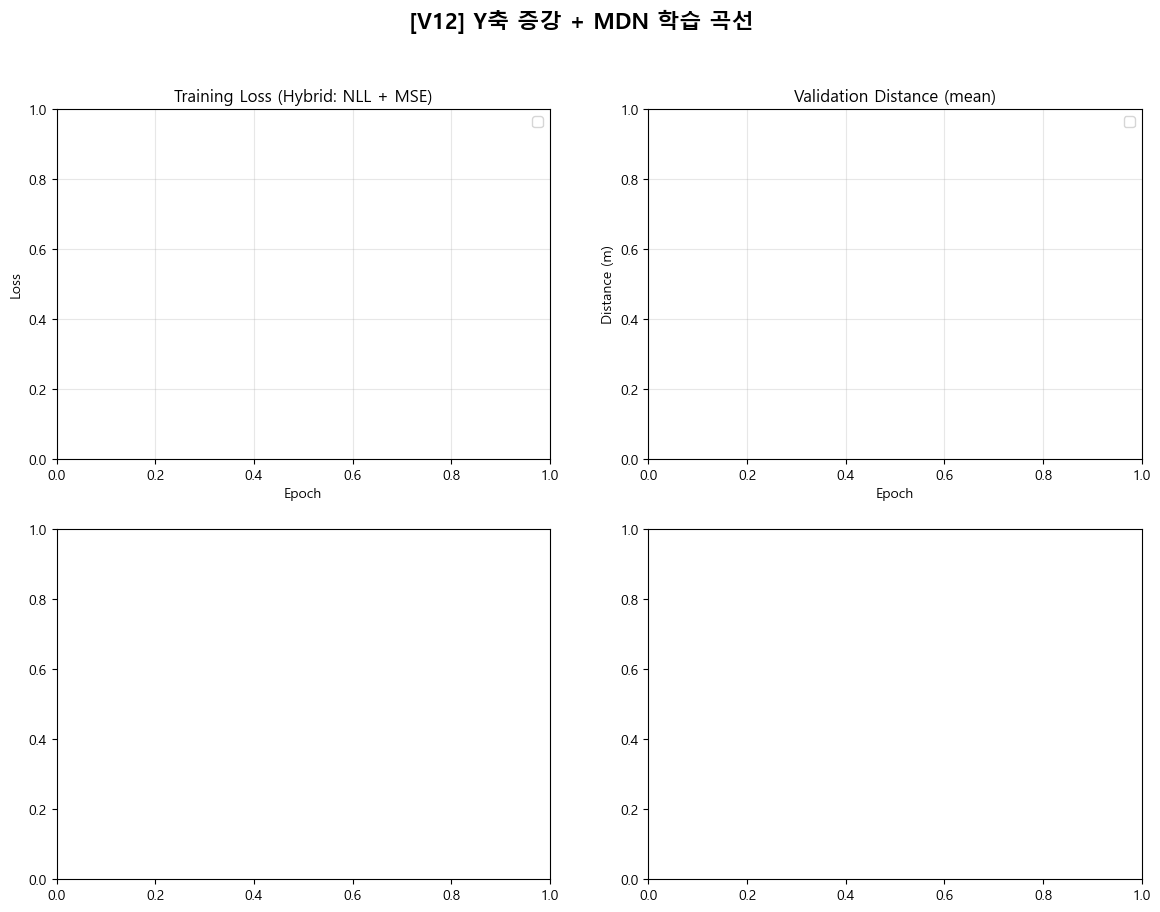

In [12]:
# 시각화
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('[V12] Y축 증강 + MDN 학습 곡선', fontsize=16, fontweight='bold')

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# 1. Hybrid Loss
ax1 = axes[0, 0]
for i, h in enumerate(all_histories):
    epochs = range(1, len(h['train_loss']) + 1)
    ax1.plot(epochs, h['train_loss'], label=f"Model {i+1}", color=colors[i], linewidth=2)
ax1.set_title('Training Loss (Hybrid: NLL + MSE)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Validation Distance
ax2 = axes[0, 1]
for i, h in enumerate(all_histories):
    epochs = range(1, len(h['val_dist']) + 1)
    ax2.plot(epochs, h['val_dist'], label=f"Model {i+1}", color=colors[i], linewidth=2)
    best_idx = np.argmin(h['val_dist'])
    ax2.scatter(best_idx + 1, h['val_dist'][best_idx], color=colors[i], s=100, marker='*')
ax2.set_title(f'Validation Distance ({PRED_STRATEGY})')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Distance (m)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. NLL vs MSE
ax3 = axes[1, 0]
h = all_histories[0]
epochs = range(1, len(h['train_nll']) + 1)
ax3.plot(epochs, h['train_nll'], label='NLL', color='red', linewidth=2)
ax3_twin = ax3.twinx()
ax3_twin.plot(epochs, h['train_mse'], label='MSE', color='blue', linewidth=2)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('NLL', color='red')
ax3_twin.set_ylabel('MSE', color='blue')
ax3.set_title('Loss Components (Model 1)')
ax3.grid(True, alpha=0.3)

# 4. Best Distances
ax4 = axes[1, 1]
best_dists = [h['best_dist'] for h in all_histories]
bars = ax4.bar(range(len(best_dists)), best_dists, color=colors)
ax4.set_xticks(range(len(best_dists)))
ax4.set_xticklabels([f'Model {i+1}' for i in range(len(best_dists))])
ax4.set_ylabel('Best Distance (m)')
ax4.set_title('Best Performance (Y축 증강)')
for bar, dist in zip(bars, best_dists):
    ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height(), 
             f'{dist:.4f}m', ha='center', va='bottom', fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('v12_y_aug_mdn_history.png', dpi=150)
plt.show()

print(f"\n최종 결과:")
for i, h in enumerate(all_histories):
    print(f"  Model {i+1}: {h['best_dist']:.4f}m")
print(f"  평균: {np.mean(best_dists):.4f}m")

V11 모델 공간적 에러 분석 (Validation Set)


Dataset (train): 100%|██████████| 3086/3086 [00:03<00:00, 922.85it/s]


Validation 데이터: 3085 episodes

🔍 Array lengths:
   Predictions: 3085
   Start coords: 3085

✅ 전체 평균 에러: 12.75m
   X 에러: 7.81m
   Y 에러: 8.20m

X축 구역별 분석
수비진영 (X: 0-35m):
  개수: 337 (10.9%)
  평균 에러: 12.68m
중원 (X: 35-70m):
  개수: 1042 (33.8%)
  평균 에러: 12.90m
공격진영 (X: 70-105m):
  개수: 1701 (55.1%)
  평균 에러: 12.64m

Y축 구역별 분석
좌측 (Y: 0.0-22.7m):
  개수: 1253 (40.6%)
  평균 에러: 12.21m
중앙 (Y: 22.7-45.3m):
  개수: 589 (19.1%)
  평균 에러: 12.86m
우측 (Y: 45.3-68.0m):
  개수: 1073 (34.8%)
  평균 에러: 11.99m


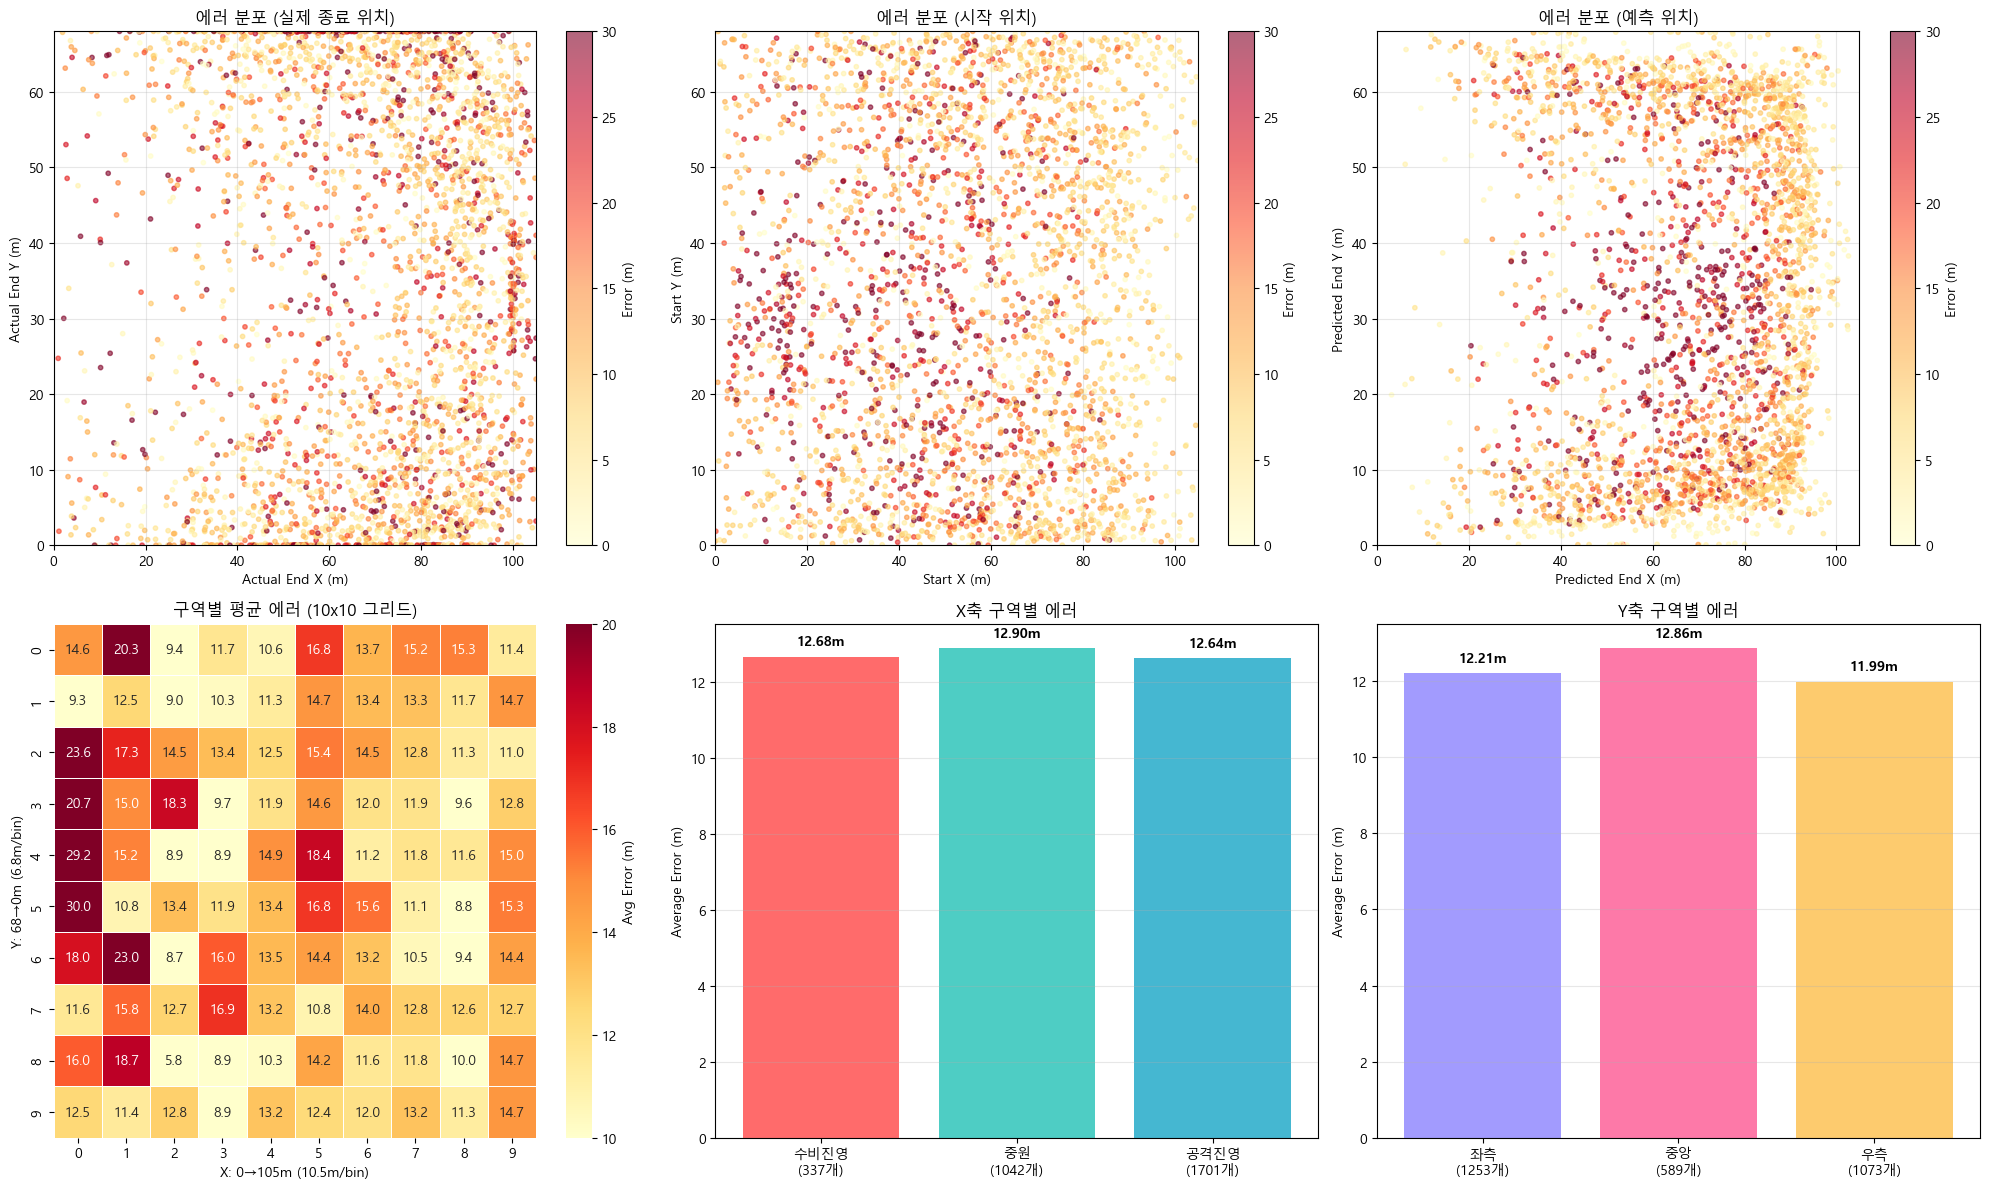


에러가 높은 구역 TOP 5
    X     Y Error  Count
84-94  7-14  9.98     64
32-42 41-48  9.69      8
84-94 41-48  9.55     43
84-94 20-27  9.43     60
21-32 61-68  9.40     39

✅ 분석 완료: v12_spatial_error_analysis.png


In [14]:
# ======================================================
# 공간적 에러 분석: 어느 지역에서 예측을 많이 틀리는가?
# ======================================================
import seaborn as sns

print("="*70)
print("V11 모델 공간적 에러 분석 (Validation Set)")
print("="*70)

# Validation 데이터로 예측 생성
seed_everything(42)
train_idx, val_idx = train_test_split(range(len(full_dataset)), test_size=0.2, random_state=42)

# Validation 데이터셋 (증강 없이!)
val_subset_df = train_df[train_df[ID_COL].isin(train_df.groupby(ID_COL).head(1).iloc[val_idx][ID_COL].values)]
val_dataset_for_analysis = SoccerDataset(val_subset_df, mode='train', augment_y=False)
val_loader_analysis = DataLoader(val_dataset_for_analysis, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Validation 데이터: {len(val_dataset_for_analysis)} episodes")

# 3개 모델로 예측
models = []
for i in range(3):
    model = ImprovedMDNPredictor(INPUT_DIM, HIDDEN_DIM, LSTM_LAYERS, DROPOUT, 
                                 NUM_GAUSSIANS, BIDIRECTIONAL).to(DEVICE)
    model.load_state_dict(torch.load(f'v12_y_aug_mdn_{i}.pth'))
    model.eval()
    models.append(model)

# 예측 수행
predictions = []
actuals = []
episode_ids = []

with torch.no_grad():
    for seqs, targets, mask, lens, team_ids in val_loader_analysis:
        seqs, mask, lens = seqs.to(DEVICE), mask.to(DEVICE), lens.to(DEVICE)
        
        # 3개 모델 앙상블
        preds = []
        for model in models:
            pi, mu, sigma = model(seqs, mask, lens)
            pred = mdn_predict_improved(pi, mu, sigma, strategy=PRED_STRATEGY)
            preds.append(pred.cpu().numpy())
        
        avg_pred = np.mean(preds, axis=0)
        predictions.extend(avg_pred)
        actuals.extend(targets.cpu().numpy())

predictions = np.array(predictions)
actuals = np.array(actuals)

# 실제 좌표로 변환
pred_x, pred_y = predictions[:, 0] * 105.0, predictions[:, 1] * 68.0
actual_x, actual_y = actuals[:, 0] * 105.0, actuals[:, 1] * 68.0

# 🔍 Validation 데이터에서 시작 위치 추출 (Dataset과 동일한 순서로!)
# Dataset 클래스가 필터링을 하므로, 동일하게 필터링된 에피소드만 사용
start_coords = []
filtered_episodes = []
for name, group in val_subset_df.groupby(ID_COL, sort=False):
    # Dataset 클래스의 필터링 조건과 동일하게 적용
    if len(group) < 2:
        continue
    
    last_row = group.iloc[-1]
    start_coords.append({
        'start_x': last_row['start_x'],
        'start_y': last_row['start_y']
    })
    filtered_episodes.append(name)

start_df = pd.DataFrame(start_coords)

# 에러 계산
errors = np.sqrt((pred_x - actual_x)**2 + (pred_y - actual_y)**2)
error_x = np.abs(pred_x - actual_x)
error_y = np.abs(pred_y - actual_y)

print(f"\n🔍 Array lengths:")
print(f"   Predictions: {len(pred_x)}")
print(f"   Start coords: {len(start_df)}")

# 길이 확인 및 조정
if len(start_df) != len(pred_x):
    print(f"\n⚠️ Length mismatch detected!")
    print(f"   Truncating to minimum length: {min(len(pred_x), len(start_df))}")
    
    min_len = min(len(pred_x), len(start_df))
    pred_x = pred_x[:min_len]
    pred_y = pred_y[:min_len]
    actual_x = actual_x[:min_len]
    actual_y = actual_y[:min_len]
    errors = errors[:min_len]
    error_x = error_x[:min_len]
    error_y = error_y[:min_len]
    start_df = start_df.iloc[:min_len]

print(f"\n✅ 전체 평균 에러: {errors.mean():.2f}m")
print(f"   X 에러: {error_x.mean():.2f}m")
print(f"   Y 에러: {error_y.mean():.2f}m")

# 데이터프레임 생성
analysis_df = pd.DataFrame({
    'pred_x': pred_x,
    'pred_y': pred_y,
    'actual_x': actual_x,
    'actual_y': actual_y,
    'start_x': start_df['start_x'].values,
    'start_y': start_df['start_y'].values,
    'error': errors,
    'error_x': error_x,
    'error_y': error_y
})

# 시각화
fig = plt.figure(figsize=(20, 12))

# 1. 실제 위치 기준 에러 분포
ax1 = plt.subplot(2, 3, 1)
scatter1 = ax1.scatter(analysis_df['actual_x'], analysis_df['actual_y'],
                       c=analysis_df['error'], cmap='YlOrRd',
                       s=10, alpha=0.6, vmin=0, vmax=30)
ax1.set_xlim(0, 105)
ax1.set_ylim(0, 68)
ax1.set_xlabel('Actual End X (m)')
ax1.set_ylabel('Actual End Y (m)')
ax1.set_title('에러 분포 (실제 종료 위치)')
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=ax1, label='Error (m)')

# 2. 시작 위치 기준 에러
ax2 = plt.subplot(2, 3, 2)
scatter2 = ax2.scatter(analysis_df['start_x'], analysis_df['start_y'],
                       c=analysis_df['error'], cmap='YlOrRd',
                       s=10, alpha=0.6, vmin=0, vmax=30)
ax2.set_xlim(0, 105)
ax2.set_ylim(0, 68)
ax2.set_xlabel('Start X (m)')
ax2.set_ylabel('Start Y (m)')
ax2.set_title('에러 분포 (시작 위치)')
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=ax2, label='Error (m)')

# 3. 예측 위치 기준
ax3 = plt.subplot(2, 3, 3)
scatter3 = ax3.scatter(analysis_df['pred_x'], analysis_df['pred_y'],
                       c=analysis_df['error'], cmap='YlOrRd',
                       s=10, alpha=0.6, vmin=0, vmax=30)
ax3.set_xlim(0, 105)
ax3.set_ylim(0, 68)
ax3.set_xlabel('Predicted End X (m)')
ax3.set_ylabel('Predicted End Y (m)')
ax3.set_title('에러 분포 (예측 위치)')
ax3.grid(True, alpha=0.3)
plt.colorbar(scatter3, ax=ax3, label='Error (m)')

# 4. 10x10 그리드 히트맵
ax4 = plt.subplot(2, 3, 4)
error_grid = np.zeros((10, 10))
count_grid = np.zeros((10, 10))

for _, row in analysis_df.iterrows():
    x_idx = min(int(row['actual_x'] / 10.5), 9)
    y_idx = min(int(row['actual_y'] / 6.8), 9)
    error_grid[9-y_idx, x_idx] += row['error']
    count_grid[9-y_idx, x_idx] += 1

error_grid = np.divide(error_grid, count_grid, where=count_grid>0, out=np.full_like(error_grid, np.nan))

sns.heatmap(error_grid, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax4, cbar_kws={'label': 'Avg Error (m)'},
            vmin=10, vmax=20, linewidths=0.5)
ax4.set_xlabel('X: 0→105m (10.5m/bin)')
ax4.set_ylabel('Y: 68→0m (6.8m/bin)')
ax4.set_title('구역별 평균 에러 (10x10 그리드)')

# 5. X축 구역별
ax5 = plt.subplot(2, 3, 5)
x_ranges = [(0, 35, '수비진영'), (35, 70, '중원'), (70, 105, '공격진영')]
x_errors = []
x_labels = []

print("\n" + "="*70)
print("X축 구역별 분석")
print("="*70)
for x_min, x_max, label in x_ranges:
    mask = (analysis_df['actual_x'] >= x_min) & (analysis_df['actual_x'] < x_max)
    avg_error = analysis_df[mask]['error'].mean()
    count = mask.sum()
    x_errors.append(avg_error)
    x_labels.append(f"{label}\n({count}개)")
    print(f"{label} (X: {x_min}-{x_max}m):")
    print(f"  개수: {count} ({count/len(analysis_df)*100:.1f}%)")
    print(f"  평균 에러: {avg_error:.2f}m")

ax5.bar(x_labels, x_errors, color=['#ff6b6b', '#4ecdc4', '#45b7d1'])
ax5.set_ylabel('Average Error (m)')
ax5.set_title('X축 구역별 에러')
ax5.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(x_errors):
    if not np.isnan(v):
        ax5.text(i, v + 0.3, f'{v:.2f}m', ha='center', fontweight='bold')

# 6. Y축 구역별
ax6 = plt.subplot(2, 3, 6)
y_ranges = [(0, 22.67, '좌측'), (22.67, 45.33, '중앙'), (45.33, 68, '우측')]
y_errors = []
y_labels = []

print("\n" + "="*70)
print("Y축 구역별 분석")
print("="*70)
for y_min, y_max, label in y_ranges:
    mask = (analysis_df['actual_y'] >= y_min) & (analysis_df['actual_y'] < y_max)
    avg_error = analysis_df[mask]['error'].mean()
    count = mask.sum()
    y_errors.append(avg_error)
    y_labels.append(f"{label}\n({count}개)")
    print(f"{label} (Y: {y_min:.1f}-{y_max:.1f}m):")
    print(f"  개수: {count} ({count/len(analysis_df)*100:.1f}%)")
    print(f"  평균 에러: {avg_error:.2f}m")

ax6.bar(y_labels, y_errors, color=['#a29bfe', '#fd79a8', '#fdcb6e'])
ax6.set_ylabel('Average Error (m)')
ax6.set_title('Y축 구역별 에러')
ax6.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(y_errors):
    if not np.isnan(v):
        ax6.text(i, v + 0.3, f'{v:.2f}m', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('v12_spatial_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# TOP 5 에러 구역
print("\n" + "="*70)
print("에러가 높은 구역 TOP 5")
print("="*70)

zone_errors = []
for i in range(10):
    for j in range(10):
        if not np.isnan(error_grid[i, j]) and count_grid[9-i, j] >= 5:  # 최소 5개 이상
            zone_errors.append({
                'X': f"{j*10.5:.0f}-{(j+1)*10.5:.0f}",
                'Y': f"{(9-i)*6.8:.0f}-{(10-i)*6.8:.0f}",
                'Error': f"{error_grid[i, j]:.2f}",
                'Count': int(count_grid[9-i, j])
            })

if zone_errors:
    zone_df = pd.DataFrame(zone_errors).sort_values('Error', ascending=False)
    print(zone_df.head(5).to_string(index=False))

print("\n" + "="*70)
print("✅ 분석 완료: v12_spatial_error_analysis.png")
print("="*70)